<a href="https://colab.research.google.com/github/konovalovae812-cmd/python_da_hw/blob/main/lisa_HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
print(f"Розмір набору даних: {df.shape}")
print(df.info())

Розмір набору даних: (10886, 19)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       10886 non-null  int64  
 1   holiday      10886 non-null  int64  
 2   workingday   10886 non-null  int64  
 3   weather      10886 non-null  int64  
 4   temp         10886 non-null  float64
 5   atemp        10886 non-null  float64
 6   humidity     10886 non-null  int64  
 7   windspeed    10886 non-null  float64
 8   casual       10886 non-null  int64  
 9   registered   10886 non-null  int64  
 10  count        10886 non-null  int64  
 11  date         10886 non-null  object 
 12  day          10886 non-null  int32  
 13  week         10886 non-null  UInt32 
 14  weekday_num  10886 non-null  int32  
 15  weekday      10886 non-null  object 
 16  year         10886 non-null  int32  
 17  month        10886 n

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


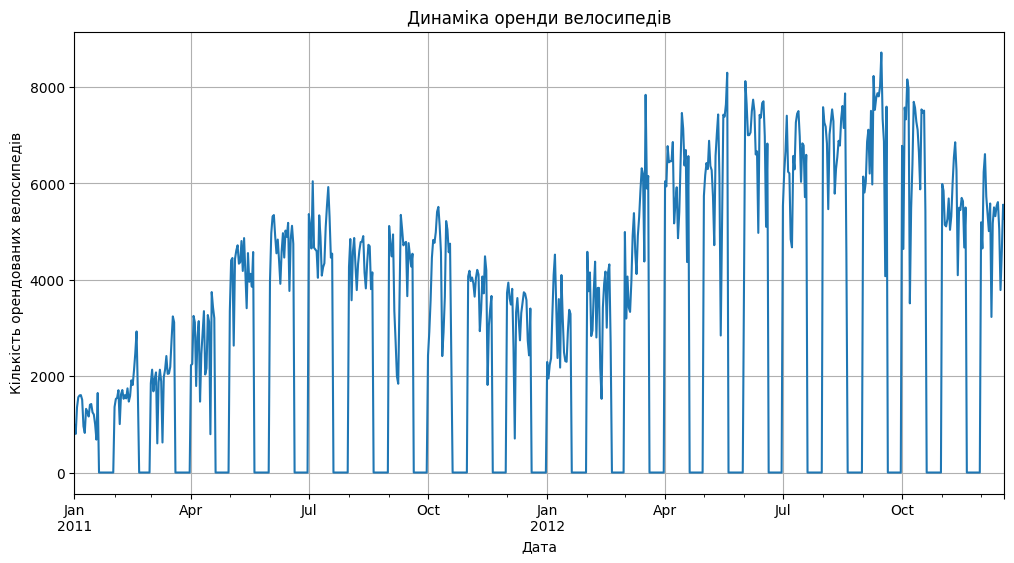

In [4]:
daily_rental = df['count'].resample('D').sum()
daily_rental.plot(
    figsize=(12, 6),
    title="Динаміка оренди велосипедів",
    grid=True
)
plt.xlabel("Дата")
plt.ylabel("Кількість орендованих велосипедів")
plt.show()


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

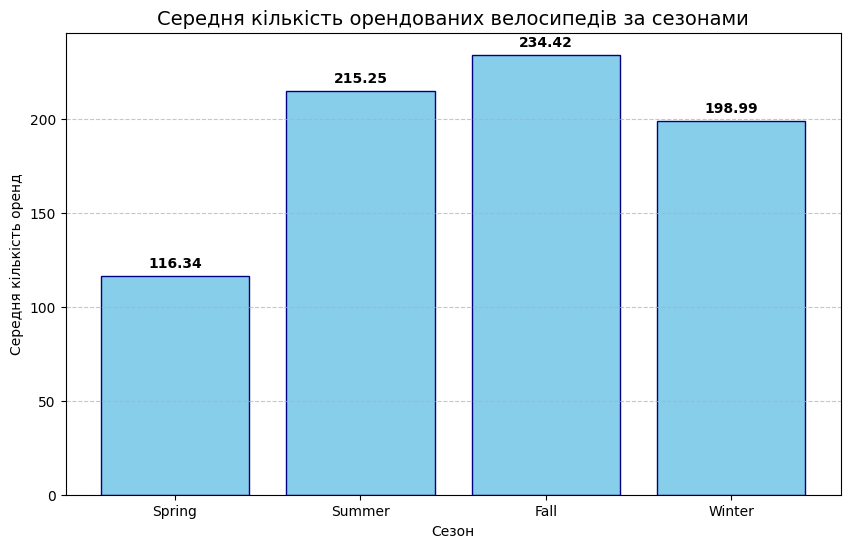

In [5]:
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}

season_avg = df.groupby('season')['count'].mean()

season_avg.index = season_avg.index.map(season_mapping)

plt.figure(figsize=(10, 6))
bars = plt.bar(season_avg.index, season_avg.values, color='skyblue', edgecolor='navy')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3, round(yval, 2),
             va='bottom', ha='center', fontweight='bold')

plt.title('Середня кількість орендованих велосипедів за сезонами', fontsize=14)
plt.xlabel('Сезон')
plt.ylabel('Середня кількість оренд')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


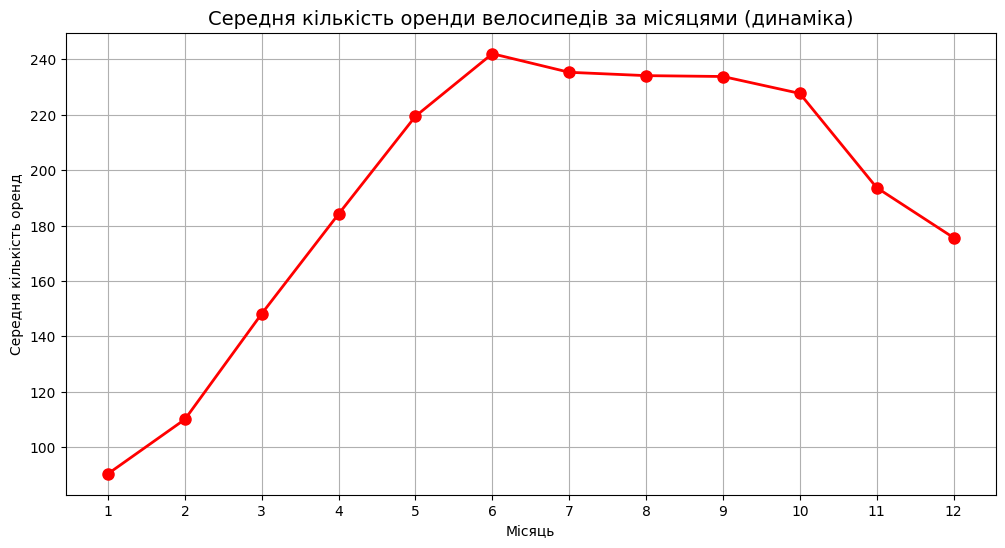

In [6]:
monthly_avg = df.groupby('month')['count'].mean()
plt.figure(figsize=(12, 6))

plt.plot(monthly_avg.index, monthly_avg.values,
         color='red',
         marker='o',
         markersize=8,
         linewidth=2)

plt.xticks(range(1, 13))

plt.title('Середня кількість оренди велосипедів за місяцями (динаміка)', fontsize=14)
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд')
plt.grid(True)

plt.show()


## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

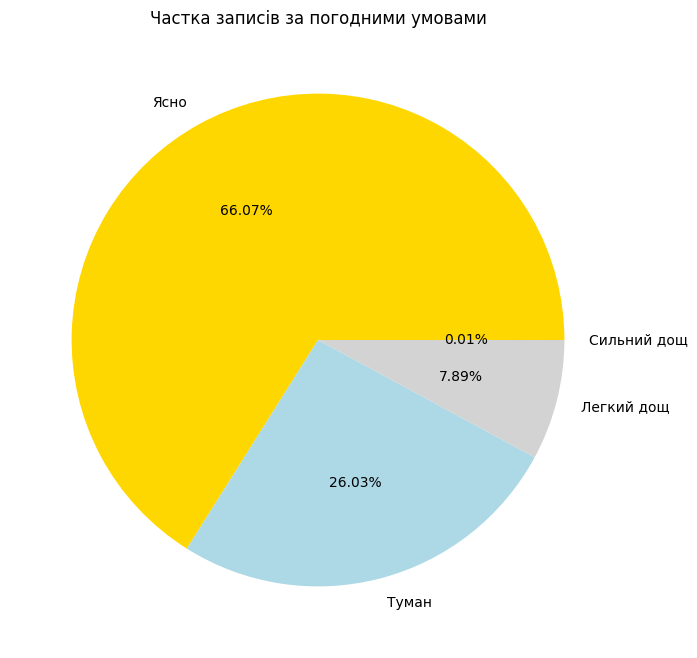

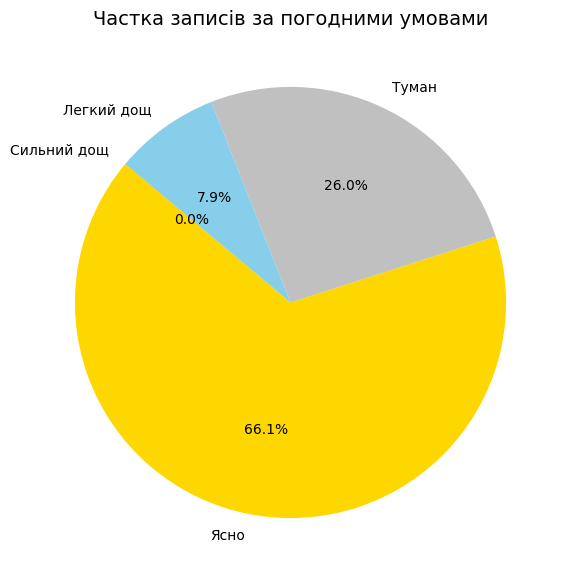

In [7]:
weather_counts = df['weather'].value_counts().sort_index()

weather_labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
custom_colors = ['#FFD700', '#C0C0C0', '#87CEEB', '#4682B4']

plt.figure(figsize=(10, 7))
plt.pie(
    weather_counts,
    labels= ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    autopct='%1.1f%%',
    startangle=140,
    colors=custom_colors,
)

plt.title('Частка записів за погодними умовами', fontsize=14)

plt.show()


## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

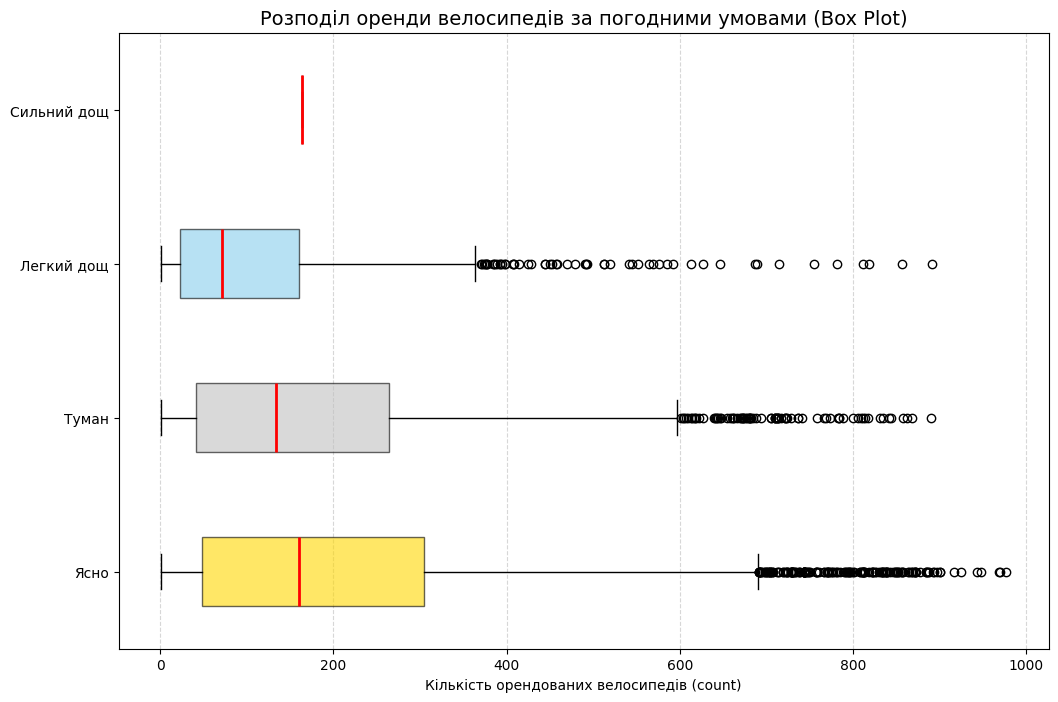

In [8]:
weather_types = [1, 2, 3, 4]
weather_names = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
data_to_plot = [df[df['weather'] == w]['count'] for w in weather_types]

plt.figure(figsize=(12, 8))

box = plt.boxplot(data_to_plot,
                  vert=False,
                  tick_labels=weather_names,
                  patch_artist=True,
                  medianprops={'color': 'red', 'linewidth': 2})

colors = ['#FFD700', '#C0C0C0', '#87CEEB', '#4682B4']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title('Розподіл оренди велосипедів за погодними умовами (Box Plot)', fontsize=14)
plt.xlabel('Кількість орендованих велосипедів (count)')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()


## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

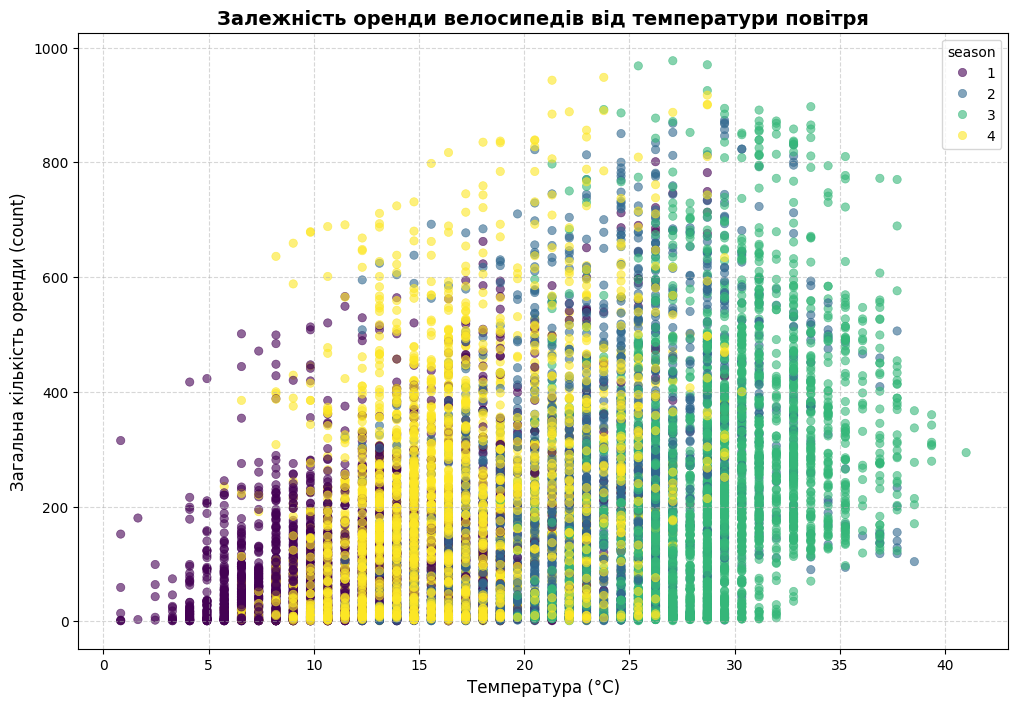

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Налаштування розміру графіка
plt.figure(figsize=(12, 8))

scatter = sns.scatterplot(
    data=df,
    x='temp',
    y='count',
    hue='season',
    palette='viridis',
    alpha=0.6,
    edgecolor=None
)


plt.title('Залежність оренди велосипедів від температури повітря', fontsize=14, fontweight='bold')
plt.xlabel('Температура (°C)', fontsize=12)
plt.ylabel('Загальна кількість оренди (count)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

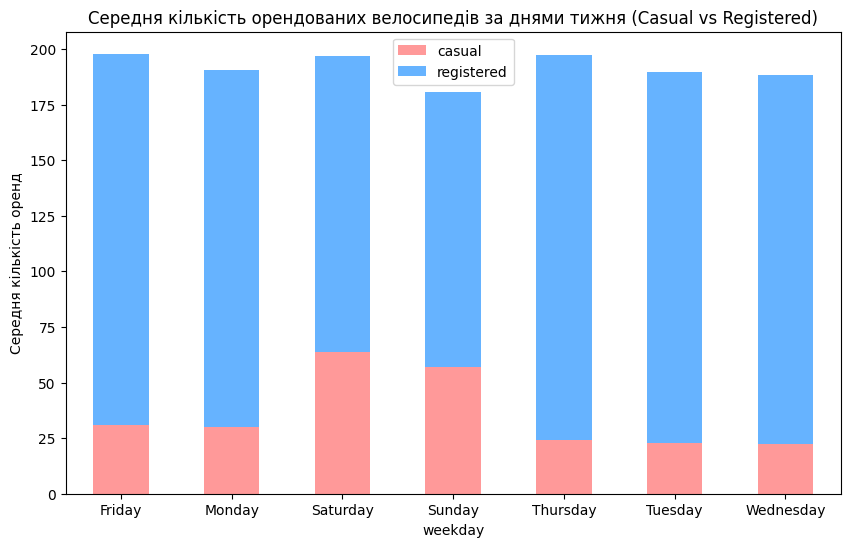

In [16]:
import matplotlib.pyplot as plt

# 1. Групуємо дані за днем тижня та обчислюємо середнє для потрібних колонок
weekly_avg = df.groupby('weekday')[['casual', 'registered']].mean()

# 2. Будуємо стовпчасту діаграму з налаштуванням stacked=True
weekly_avg.plot(kind='bar',
                stacked=True,
                figsize=(10, 6),
                color=['#ff9999', '#66b3ff'])

# Додаємо підписи
plt.title('Середня кількість орендованих велосипедів за днями тижня (Casual vs Registered)')
plt.ylabel('Середня кількість оренд')
plt.xticks(rotation=0)

plt.show()
